# Imports

In [ ]:
import sklearn
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datasets


## Real world dataset


In [ ]:
def load_real_data():
  dataset = sklearn.datasets.load_diabetes( return_X_y=False, as_frame=False)
  X = dataset.data
  Y = dataset.target
  return X, Y

## Synthetic dataset


In [ ]:
def generate_synthetic_data(n_samples=200, n_features=20, noise=5.0, seed=42):
    np.random.seed(seed)

    # Create correlated features
    X = np.random.randn(n_samples, n_features)

    # Introduce correlation (important for ridge usefulness)
    X[:, 1] = X[:, 0] + 0.01 * np.random.randn(n_samples)
    X[:, 2] = X[:, 0] - 0.01 * np.random.randn(n_samples)

    # True weights (sparse-ish)
    true_w = np.zeros(n_features)
    true_w[:5] = [5, -3, 2, 0, 1]

    # Generate targets
    y = X @ true_w + noise * np.random.randn(n_samples)

    return X, y, true_w

# Data augmentation helpers


Create the training, test, val  split

In [ ]:


def train_val_test_split(X, y, seed=42):
  X_train_full, X_test, y_train_full, y_test = train_test_split(
      X, y, test_size=0.2, random_state=seed
  )
  X_train, X_val, y_train, y_val = train_test_split(
      X_train_full, y_train_full, test_size=0.25, random_state=seed
  )
  return X_train, X_val, X_test, y_train, y_val, y_test


Add a bias to the datapoints, enables the model to learn the intercept

In [ ]:
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]



# helper functions

Determine simple functions

In [ ]:
#Error

def calculcateError( label, predi):
  # square error
  predictionError = ( predi - label ) ** 2
  ''' print( predictionError)  '''
  return predictionError


''' def sumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = calculcateError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError '''


# Non squared error
''' def simpleError( label, predi):
  predictionError =  predi - label
  print( predictionError)
  return predictionError
 '''



# Non squared error
''' def simpleSumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = simpleError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError '''

#Mean squared error
def mse(y_pred, y):
    return np.mean((y_pred - y) ** 2)


# crude and easy implementation of a prediction
def predict(X, w):
    return X @ w


In [ ]:

def getFeatureBlame( X, y, y_pred):

    # figure out how each feature contributed to those errors
    return (X.T @ (y_pred - y))

Ridge specific helpers

In [ ]:
# ridge gradiant helper

def getRidgeGradient(alpha, w):

  reg = 2 * alpha * w
  reg[0] = 0
  return reg

# Ridge model

In [ ]:
# L2, ridge
def ridge(X, y, alpha = 1, lR = 0.001, epochs = 10000):


  prev_loss = float("inf")

  # Get the shape so this is mode modular to use
  m, n = X.shape

  # Create weights
  w = np.zeros(n)

  for i in range(epochs):
    #
    y_pred = predict(X, w)


    ''' loss  = sumError(y_pred, y) '''
    loss = mse(y_pred, y) + alpha * np.sum(w[1:]**2)
    # Drop learning rate if we see no  development
    if loss >= prev_loss:
      lR *= 0.8
    prev_loss = loss

    gradient = (2 / m) *  getFeatureBlame(X, y ,y_pred) + getRidgeGradient(alpha, w)
    '''   print(gradient) '''
    # update weights
    w = w - lR * gradient


    ''' print(w ) '''
  return w

## model fitting helper



Fiddleling around with alpha and learning rate to find a good candidate or in a way "fitting" the model.

In [ ]:
#Only used in the training part
def fitRidge(X_train, X_val, y_train, y_val, epochs= 1000, alphas = [ 1e-4, 1e-3, 1e-2, 1e-1, 1, 10], lrs = [  1e-4 , 1e-3, 1e-2]):
  best_mse = float("inf")
  best_alpha = None
  best_lr = None
  best_w = None

  for alpha in alphas:
    '''  for alpha in np.logspace(-4, 3, 20): '''
    for lr in lrs:

      w = ridge(  X_train, y_train, alpha=alpha, lR=lr, epochs = epochs)
      pred = predict(X_val, w)
      current_mse = mse(pred, y_val)
      print("alpha: ", alpha,"lr: ", lr,"mse: ", current_mse)

      # Look if the score is worse or same
      if current_mse < best_mse:
        # Update best variables
        best_mse = current_mse
        best_alpha = alpha
        best_lr = lr
        best_w = w

    print("alpha:", alpha, "||w||:", np.linalg.norm(w))
  print("\nBEST RESULT:")
  print("alpha:", best_alpha, "lr:", best_lr, "mse:", best_mse)

  return best_w





# Data preprosessing

## Real world dataset

In [ ]:
# load and assingn permuntation
X_real, Y_real = load_real_data()


# Split data
X_real_train,X_real_val, X_real_test, y_real_train, y_real_val, y_real_test  = train_val_test_split(X_real, Y_real)

# Add bias to learn intercept
X_real_train = add_bias(X_real_train)
X_real_val = add_bias(X_real_val)
X_real_test = add_bias(X_real_test)



## Synthetic dataset

In [ ]:
# load and assingn permuntation
X_synt, Y_synt, synth_true_w = generate_synthetic_data(n_samples=120, n_features=80, noise=3.0, seed=42)

# Split data
X_synt_train,X_synt_val, X_synt_test, y_synt_train,y_synt_val, y_synt_test  = train_val_test_split(X_synt, Y_synt)

# Add bias to learn intercept
X_synt_train = add_bias(X_synt_train)
X_synt_val = add_bias(X_synt_val)
X_synt_test = add_bias(X_synt_test)


# Development training

This part was used to test and see what the model could do, not really important to the assignment. The actual assingment starts at Assignment start

In [ ]:
def checkPredictions(testPredictions, y_test):
  for i in range(10):
    print("Error for " + str(i)
        + ": " + str(calculcateError(testPredictions[i], y_test[i]))
        + ", Prediction: " + str(testPredictions[i])
        + ", label : " +str( y_test[i]))
  return

In [ ]:
def visualizeTraining( testPredictions, X_test, y_test):
    num_samples_to_plot = len(X_test)
    indices = np.arange(num_samples_to_plot)

    plt.figure(figsize=(15, 6))
    plt.plot(indices, y_test[:num_samples_to_plot], 'b-', label='Actual')
    plt.plot(indices, testPredictions[:num_samples_to_plot], 'r--', label='Predicted')
    plt.title('Model Predictions vs Actual Values (Test Data)')
    plt.xlabel('Sample Index')
    plt.ylabel('Value')
    plt.legend()
    plt.show()


    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, testPredictions, alpha=0.7)
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title("True vs Predicted")

    min_val = min(y_test.min(), testPredictions.min())
    max_val = max(y_test.max(), testPredictions.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.show()


    return

In [ ]:
# Fits a model and prints evaluation metrics against test set of the best model
def TrainingModelFlow(X_train, X_val, X_test, y_train, y_val, y_test):
  # Retrieve ridge weights from a crude implementation
  best_real_w = fitRidge(X_train, X_val, y_train, y_val, epochs = 20000, alphas = [ 1e-4, 1e-3, 1e-2, 1e-1, 1, 10], lrs = [  1e-4 , 1e-3, 1e-2])



  testPredictions = predict(X_test, best_real_w)
  print("\nTesting against test set")


  mse_test = mse(y_test, testPredictions)
  rmse_test = np.sqrt(mse_test)
  print("test set MSE: ",mse_test,"RMSE: ", rmse_test)

  # Shows first 10 predictions and their correct labels
  checkPredictions(testPredictions, y_test)


  # Visualize
  visualizeTraining(testPredictions, X_test, y_test)
  return

## Real world dataset

alpha:  0.0001 lr:  0.0001 mse:  5647.556213344757
alpha:  0.0001 lr:  0.001 mse:  4465.808156601482
alpha:  0.0001 lr:  0.01 mse:  2723.0714573475416
alpha: 0.0001 ||w||: 657.4361110411792
alpha:  0.001 lr:  0.0001 mse:  5647.8538641310915
alpha:  0.001 lr:  0.001 mse:  4483.980119130438
alpha:  0.001 lr:  0.01 mse:  2813.2859281694496
alpha: 0.001 ||w||: 588.3708537117327
alpha:  0.01 lr:  0.0001 mse:  5650.792101085531
alpha:  0.01 lr:  0.001 mse:  4648.883765402144
alpha:  0.01 lr:  0.01 mse:  3826.088910046012
alpha: 0.01 ||w||: 298.17854568420194
alpha:  0.1 lr:  0.0001 mse:  5676.69099000209
alpha:  0.1 lr:  0.001 mse:  5351.041416230517
alpha:  0.1 lr:  0.01 mse:  5346.245157328456
alpha: 0.1 ||w||: 155.0546168120408
alpha:  1 lr:  0.0001 mse:  5773.249154751518
alpha:  1 lr:  0.001 mse:  5679.862130326237
alpha:  1 lr:  0.01 mse:  5679.861586766395
alpha: 1 ||w||: 149.85874596154778
alpha:  10 lr:  0.0001 mse:  5810.038044854451
alpha:  10 lr:  0.001 mse:  5717.103632019271
al

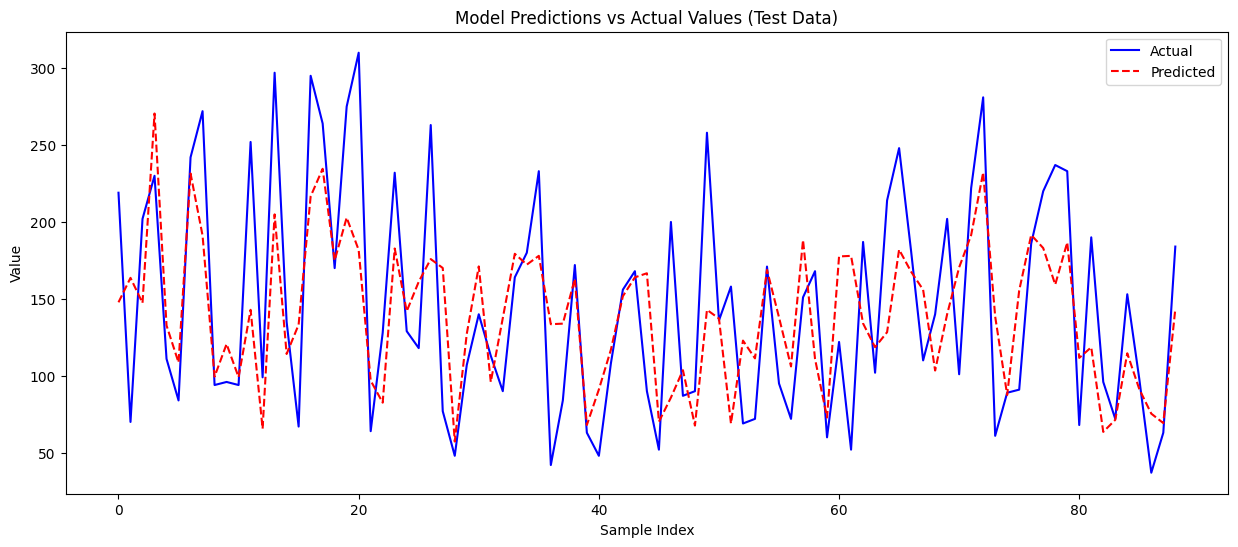

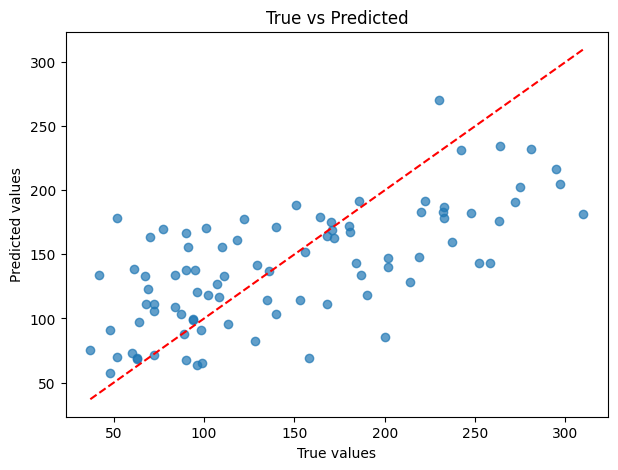

In [ ]:
#Test real world data
TrainingModelFlow(X_real_train, X_real_val, X_real_test, y_real_train, y_real_val, y_real_test)



## Synthetic dataset


alpha:  0.0001 lr:  0.0001 mse:  9.418554262661255
alpha:  0.0001 lr:  0.001 mse:  14.390934348639163
alpha:  0.0001 lr:  0.01 mse:  46.74393967879572
alpha: 0.0001 ||w||: 8.284229864524708
alpha:  0.001 lr:  0.0001 mse:  9.418154400552767
alpha:  0.001 lr:  0.001 mse:  14.246117438834617
alpha:  0.001 lr:  0.01 mse:  40.730649741293966
alpha: 0.001 ||w||: 7.8206894925694606
alpha:  0.01 lr:  0.0001 mse:  9.415315145903739
alpha:  0.01 lr:  0.001 mse:  13.073473912819948
alpha:  0.01 lr:  0.01 mse:  19.344285869561585
alpha: 0.01 ||w||: 5.7020524597353
alpha:  0.1 lr:  0.0001 mse:  9.481723833650575
alpha:  0.1 lr:  0.001 mse:  10.223801792532432
alpha:  0.1 lr:  0.01 mse:  10.255996668385805
alpha: 0.1 ||w||: 3.632508383520866
alpha:  1 lr:  0.0001 mse:  12.06909231344113
alpha:  1 lr:  0.001 mse:  12.200036309539954
alpha:  1 lr:  0.01 mse:  12.200039014616033
alpha: 1 ||w||: 2.0100042417322515
alpha:  10 lr:  0.0001 mse:  20.388453755573188
alpha:  10 lr:  0.001 mse:  20.38935683530

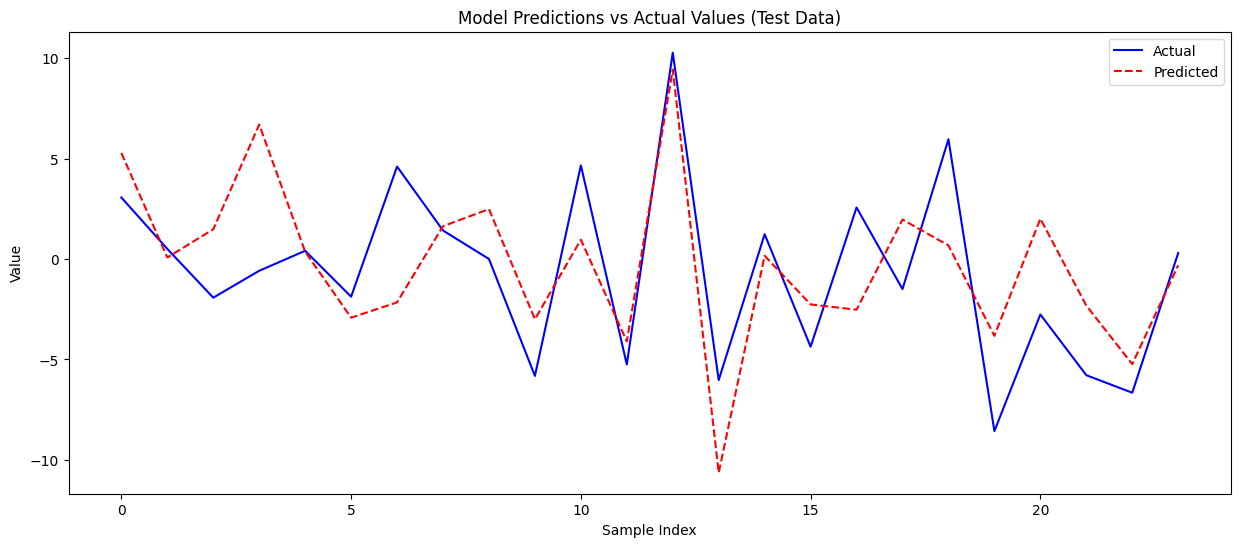

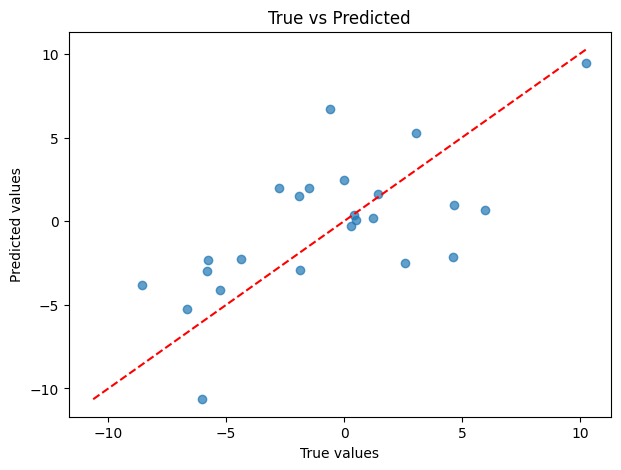

In [ ]:

#Test synthetic data
TrainingModelFlow(X_synt_train, X_synt_val, X_synt_test, y_synt_train, y_synt_val, y_synt_test)


# Assignment start



Actual assingment part, testing for regulation correlation and generalization to stability


In [ ]:

# Defining Similar function to the fitRidge, but with small changes
# Training was for to see if the idea works
def fit_fixed_alpha(X_train, X_val, y_train, y_val, alpha, epochs=5000, lrs=[1e-4, 1e-3, 1e-2]):
    best_val_mse = float("inf")
    best_lr = None
    best_w = None

    for lr in lrs:
        w = ridge(X_train, y_train, alpha=alpha, lR=lr, epochs=epochs)
        pred_val = predict(X_val, w)
        val_mse = mse(pred_val, y_val)

        # See if the math "overflows" and skip that value combination
        if np.isnan(val_mse) or np.isinf(val_mse):
            continue

        # Similar to fidRidge
        # We check the validation MSE and take the best score's hyperparameters
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_lr = lr
            best_w = w

    if best_w is None:
        return None

    # Make a last prediction and return variables
    train_pred = predict(X_train, best_w)
    val_pred = predict(X_val, best_w)

    return {
        "alpha": alpha,
        "lr": best_lr,
        "w": best_w,
        "train_mse": mse(train_pred, y_train),
        "val_mse": mse(val_pred, y_val)
    }


In [ ]:
def estimate_stability(X_train, y_train, X_val, y_val, X_test, y_test,
                       alpha, epochs=3000, lrs=[1e-4, 1e-3, 1e-2], ):

    # Calculate average absolute change in predictions on the fixed test set
    # after removing one training point and retraining.

    base_result = fit_fixed_alpha(X_train, X_val, y_train, y_val, alpha, epochs=epochs, lrs=lrs)

    if base_result is None:
        return None

    # Best variables
    base_w = base_result["w"]
    base_lr = base_result["lr"]
    base_test_pred = predict(X_test, base_w)
    base_test_mse = mse(base_test_pred, y_test)

    # Datapoints for the remove i loop
    n_train = X_train.shape[0]
    indices = np.arange(n_train)


    prediction_changes = []
    loss_changes = []

    for i in indices:
        # Remove a training point
        X_train_minus_i = np.delete(X_train, i, axis=0)
        y_train_minus_i = np.delete(y_train, i, axis=0)

        # Keep alpha fixed and use the same learning rate chosen on validation set
        w_minus_i = ridge(X_train_minus_i, y_train_minus_i, alpha=alpha, lR=base_lr, epochs=epochs)
        pred_minus_i = predict(X_test, w_minus_i)

        pred_change = np.mean(np.abs(base_test_pred - pred_minus_i))
        loss_change = abs(mse(pred_minus_i, y_test) - base_test_mse)

        prediction_changes.append(pred_change)
        loss_changes.append(loss_change)

    return {
        "alpha": alpha,
        "lr": base_lr,
        "train_mse": base_result["train_mse"],
        "val_mse": base_result["val_mse"],
        "test_mse": base_test_mse,
        "stability_pred": np.mean(prediction_changes),
        "stability_loss": np.mean(loss_changes)
    }

In [ ]:
def run_stability_experiment(X_train, y_train, X_val, y_val, X_test, y_test,
                             alphas = np.logspace(-6, 2, 12),
                             epochs=3000,
                             lrs=[1e-4, 1e-3, 1e-2],
                             ):
    results = []

    for alpha in alphas:
        result = estimate_stability(
            X_train, y_train, X_val, y_val, X_test, y_test,
            alpha=alpha,
            epochs=epochs,
            lrs=lrs,

        )

        if result is not None:
            results.append(result)
            print(
                "alpha:", result["alpha"],
                "| lr:", result["lr"],
                "| train_mse:", result["train_mse"],
                "| test_mse:", result["test_mse"],
                "| stability_pred:", result["stability_pred"],
                "| stability_loss:", result["stability_loss"]
            )

    return pd.DataFrame(results)

## Visualization helper

In [ ]:
def plot_stability_results(df, title_prefix="Dataset"):
    alpha_labels = [str(a) for a in df["alpha"]]
    x = np.arange(len(df))

    # Train vs test error
    plt.figure(figsize=(10, 5))
    plt.plot(x, df["train_mse"], marker='o', label="Train MSE")
    plt.plot(x, df["test_mse"], marker='s', label="Test MSE")
    plt.xticks(x, alpha_labels)
    plt.xlabel("alpha")
    plt.ylabel("MSE")
    plt.title(f"{title_prefix}: Train/Test error vs regularization")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Stability based on prediction change
    plt.figure(figsize=(10, 5))
    plt.plot(x, df["stability_pred"], marker='o')
    plt.xticks(x, alpha_labels)
    plt.xlabel("alpha")
    plt.ylabel("Average prediction change")
    plt.title(f"{title_prefix}: Stability vs regularization")
    plt.grid(True)
    plt.show()

    # Stability based on loss change
    plt.figure(figsize=(10, 5))
    plt.plot(x, df["stability_loss"], marker='o')
    plt.xticks(x, alpha_labels)
    plt.xlabel("alpha")
    plt.ylabel("Average change in test MSE")
    plt.title(f"{title_prefix}: Stability (loss-based) vs regularization")
    plt.grid(True)
    plt.show()

## Real world dataset

alpha: 0 | lr: 0.01 | train_mse: 4699.3700685498925 | test_mse: 3929.88035930333 | stability_pred: 0.22587107228933914 | stability_loss: 4.164610543205569
alpha: 0.0001 | lr: 0.01 | train_mse: 4702.7222435642225 | test_mse: 3932.8002164158975 | stability_pred: 0.22588494075766996 | stability_loss: 4.160942057449199
alpha: 0.001 | lr: 0.01 | train_mse: 4732.526887993588 | test_mse: 3958.798570268326 | stability_pred: 0.22603197451228824 | stability_loss: 4.126719899449291
alpha: 0.01 | lr: 0.01 | train_mse: 4995.492775416074 | test_mse: 4190.813651558311 | stability_pred: 0.2288917220373889 | stability_loss: 3.7244573714536093
alpha: 0.1 | lr: 0.01 | train_mse: 5877.527529228066 | test_mse: 4995.241711548715 | stability_pred: 0.24621900538426145 | stability_loss: 1.824296007030336
alpha: 1 | lr: 0.01 | train_mse: 6179.349193047119 | test_mse: 5278.99262272216 | stability_pred: 0.25271462286900515 | stability_loss: 1.9519480901848971
alpha: 3 | lr: 0.01 | train_mse: 6204.171215294433 | t

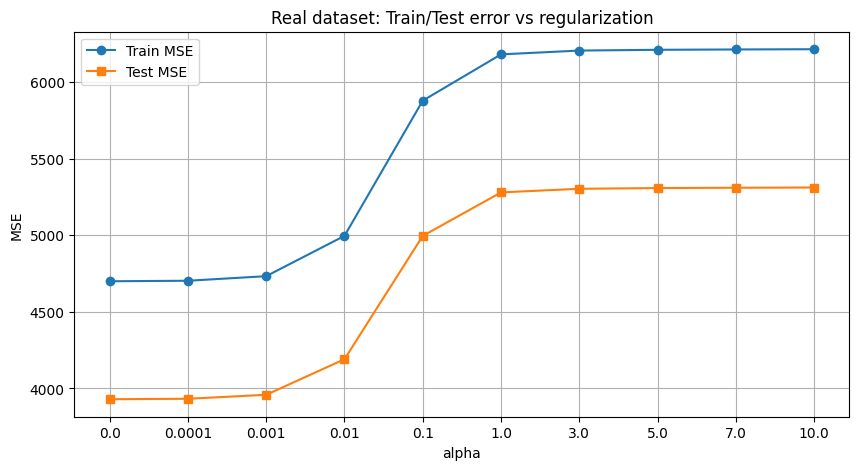

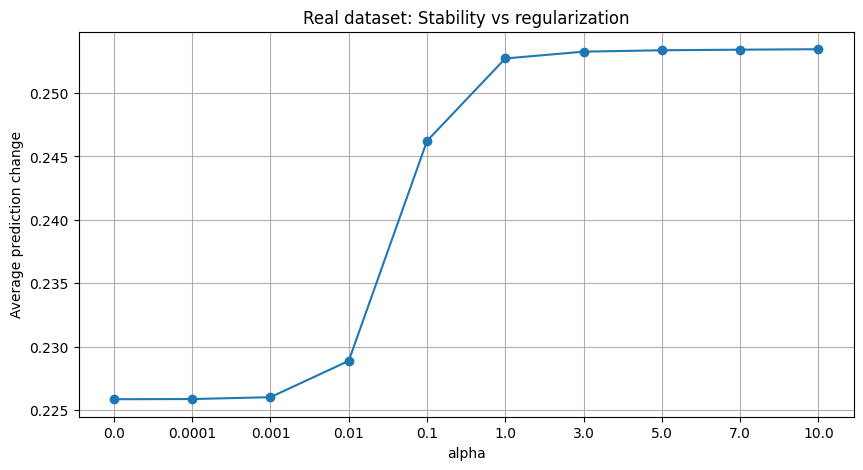

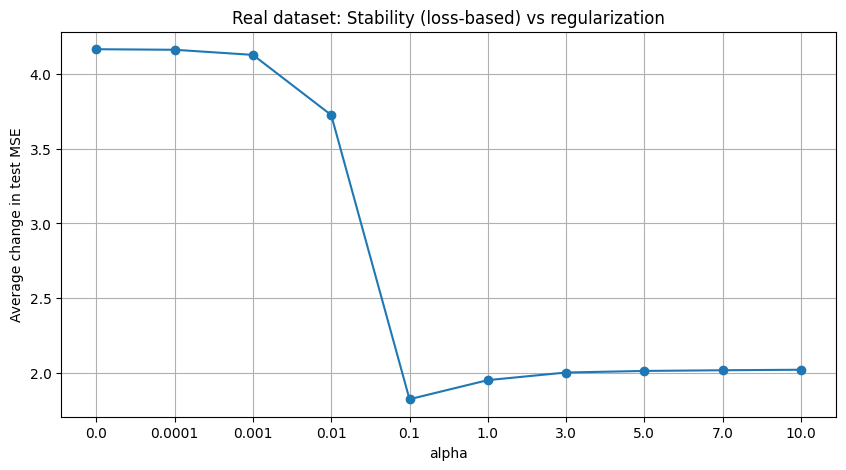

In [ ]:
real_results_df = run_stability_experiment(
    X_real_train, y_real_train,
    X_real_val, y_real_val,
    X_real_test, y_real_test,
    alphas=[0, 1e-4, 1e-3, 1e-2, 1e-1, 1, 3, 5, 7, 10],
    epochs=3000,
    lrs=[1e-4, 1e-3, 1e-2]

)

print(real_results_df)
plot_stability_results(real_results_df, title_prefix="Real dataset")

## Synthetic dataset

alpha: 0 | lr: 0.001 | train_mse: 0.7126870206727449 | test_mse: 15.528694218797403 | stability_pred: 0.31446622947237973 | stability_loss: 0.6158140940718775
alpha: 0.0001 | lr: 0.001 | train_mse: 0.7129252387109853 | test_mse: 15.525072669230783 | stability_pred: 0.3143984165697229 | stability_loss: 0.6156211353688629
alpha: 0.001 | lr: 0.001 | train_mse: 0.7150766839806258 | test_mse: 15.492577195514135 | stability_pred: 0.3137908851996086 | stability_loss: 0.6138887097356317
alpha: 0.01 | lr: 0.001 | train_mse: 0.7373070321554607 | test_mse: 15.17715843625092 | stability_pred: 0.30783776225257015 | stability_loss: 0.5969724866875088
alpha: 0.1 | lr: 0.001 | train_mse: 1.0109952364405632 | test_mse: 12.797853901280057 | stability_pred: 0.2583777054489572 | stability_loss: 0.46357882961525515
alpha: 1 | lr: 0.001 | train_mse: 3.9092047797201466 | test_mse: 9.531576086716436 | stability_pred: 0.1167333001229276 | stability_loss: 0.19446613374961047
alpha: 3 | lr: 0.001 | train_mse: 7.

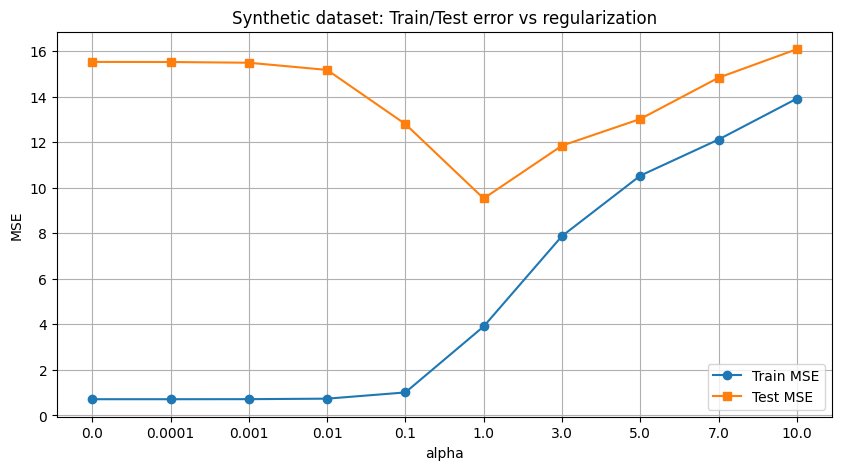

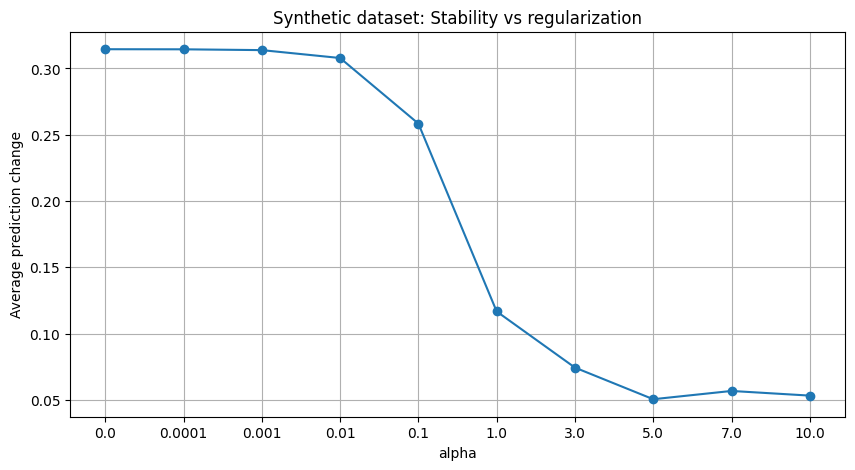

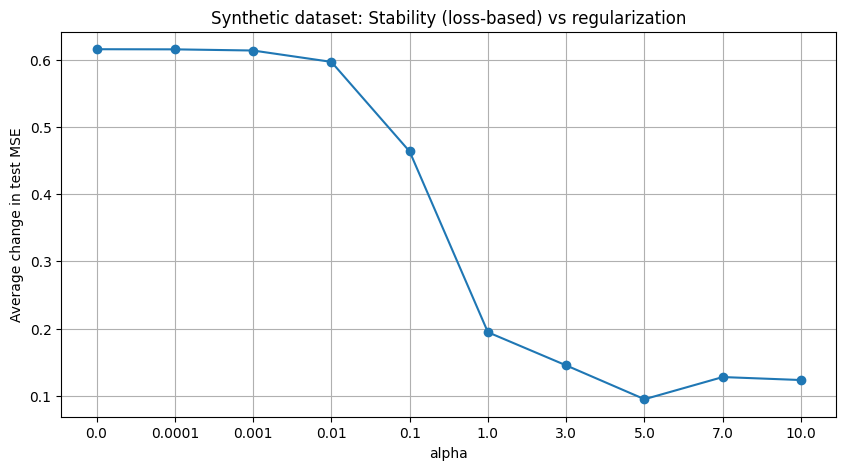

In [ ]:
synthetic_results_df = run_stability_experiment(
    X_synt_train, y_synt_train,
    X_synt_val, y_synt_val,
    X_synt_test, y_synt_test,
    alphas=[0, 1e-4, 1e-3, 1e-2, 1e-1, 1, 3, 5, 7, 10],
    epochs=3000,
    lrs=[1e-4, 1e-3, 1e-2]

)

print(synthetic_results_df)
plot_stability_results(synthetic_results_df, title_prefix="Synthetic dataset")